<a href="https://colab.research.google.com/github/srinivas340/ml_practice/blob/main/car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [1]:
!pip install kagglehub


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
Path to dataset files: /kaggle/input/vehicle-dataset-from-cardekho


In [5]:
import os
# See all the CSV files inside the downloaded folder
files = os.listdir(path)
print("Files available:", files)
# Let's load the first file in the folder
csv_file_path = f"{path}/{files[0]}"
# Or, to load a specific one explicitly:
# csv_file_path = f"{path}/car data.csv"
df = pd.read_csv(csv_file_path)
# View the first 5 rows of the vehicle data
df.head()

Files available: ['car data.csv', 'car details v4.csv', 'CAR DETAILS FROM CAR DEKHO.csv', 'Car details v3.csv']


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.shape

(301, 9)

In [7]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [11]:
df['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


In [12]:
df['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [14]:
# encoding "Fuel_Type" Column
df.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
# encoding "Seller_Type" Column
df.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
# encoding "Transmission" Column
df.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipykernel_2634/3151609631.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
/tmp/ipykernel_2634/3151609631.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
/tmp/ipykernel_2634/3151609631.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in

In [15]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [16]:
X=df.drop(['Car_Name','Selling_Price'],axis=1)
Y=df['Selling_Price']

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2)

In [18]:
model1 = LinearRegression()
model1.fit(X_train,Y_train)

LinearRegression()

In [19]:
X_train_prediction = model1.predict(X_train)
training_data_accuracy = metrics.r2_score(X_train_prediction, Y_train)
print("R squared Error : ", training_data_accuracy)

R squared Error :  0.8635655509198777


In [20]:
X_test_prediction = model1.predict(X_test)
test_data_accuracy = metrics.r2_score(X_test_prediction, Y_test)
print("R squared Error : ", test_data_accuracy)

R squared Error :  0.8062199941176358


### Linear Regression Visualization
Let's visualize the training and testing predictions for the Linear Regression model.

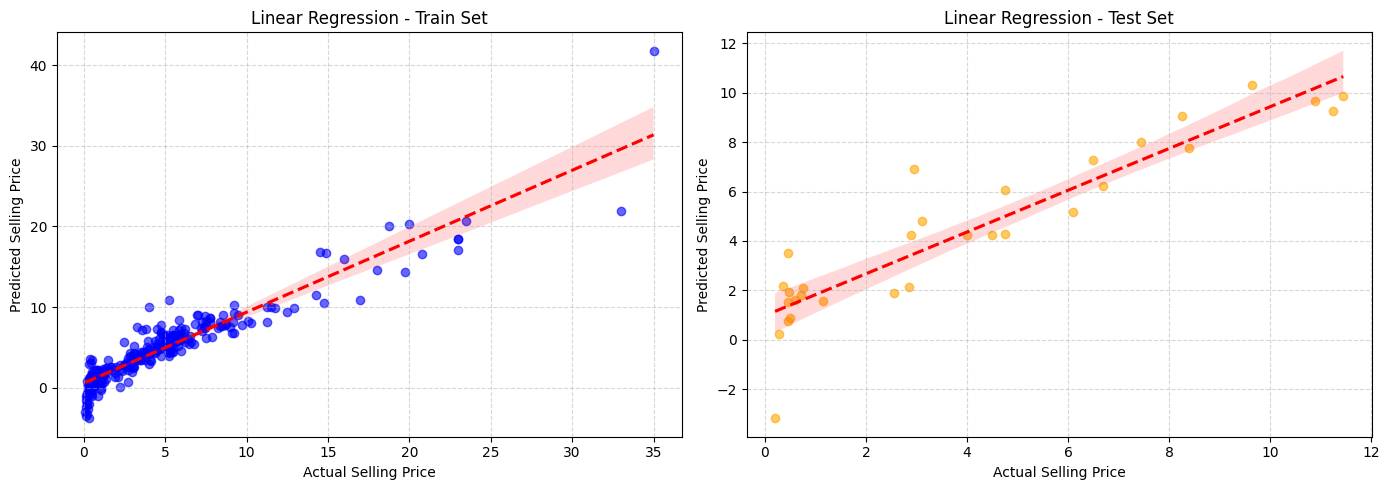

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Train Set
sns.regplot(x=Y_train, y=model1.predict(X_train), ax=ax1,
            scatter_kws={'alpha':0.6, 'color':'blue'},
            line_kws={'color':'red', 'linestyle':'--'})
ax1.set_title('Linear Regression - Train Set')
ax1.set_xlabel('Actual Selling Price')
ax1.set_ylabel('Predicted Selling Price')
ax1.grid(True, linestyle='--', alpha=0.5)

# Test Set
sns.regplot(x=Y_test, y=model1.predict(X_test), ax=ax2,
            scatter_kws={'alpha':0.6, 'color':'orange'},
            line_kws={'color':'red', 'linestyle':'--'})
ax2.set_title('Linear Regression - Test Set')
ax2.set_xlabel('Actual Selling Price')
ax2.set_ylabel('Predicted Selling Price')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [21]:
model2=Lasso()
model2.fit(X_train,Y_train)

Lasso()

In [22]:
X_train_prediction = model2.predict(X_train)
training_data_accuracy = metrics.r2_score(X_train_prediction, Y_train)
print("R squared Error : ", training_data_accuracy)

R squared Error :  0.798459024070425


In [23]:
X_test_prediction = model2.predict(X_test)
test_data_accuracy = metrics.r2_score(X_test_prediction, Y_test)
print("R squared Error : ", test_data_accuracy)

R squared Error :  0.7711110403265475


### Lasso Regression Visualization
Let's visualize the training and testing predictions for the Lasso Regression model.

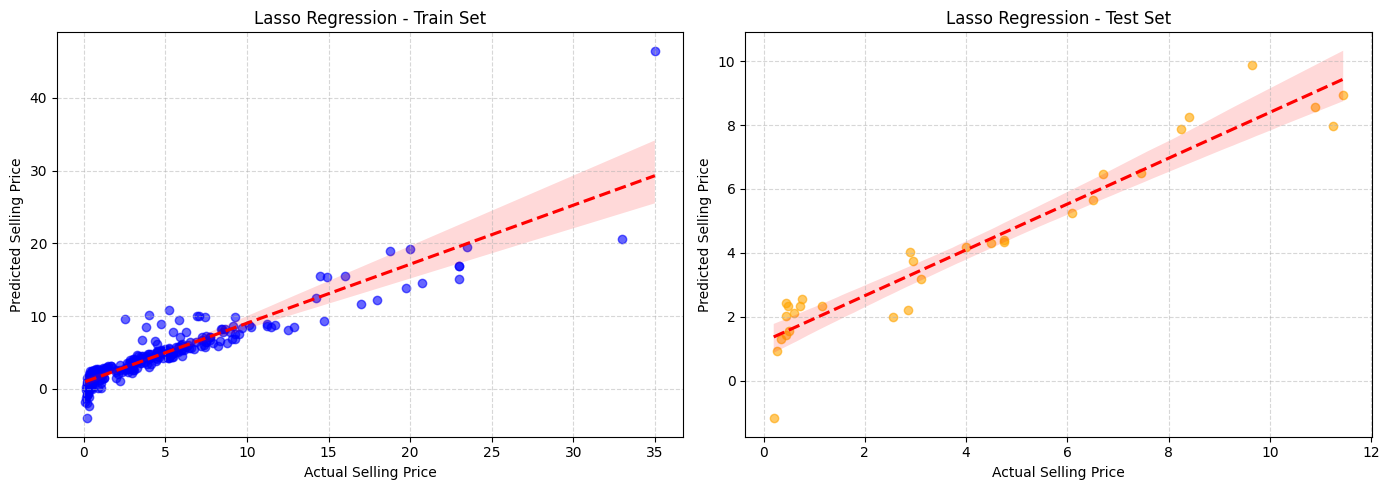

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Train Set
sns.regplot(x=Y_train, y=model2.predict(X_train), ax=ax1,
            scatter_kws={'alpha':0.6, 'color':'blue'},
            line_kws={'color':'red', 'linestyle':'--'})
ax1.set_title('Lasso Regression - Train Set')
ax1.set_xlabel('Actual Selling Price')
ax1.set_ylabel('Predicted Selling Price')
ax1.grid(True, linestyle='--', alpha=0.5)

# Test Set
sns.regplot(x=Y_test, y=model2.predict(X_test), ax=ax2,
            scatter_kws={'alpha':0.6, 'color':'orange'},
            line_kws={'color':'red', 'linestyle':'--'})
ax2.set_title('Lasso Regression - Test Set')
ax2.set_xlabel('Actual Selling Price')
ax2.set_ylabel('Predicted Selling Price')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.ensemble import RandomForestRegressor
model3=RandomForestRegressor()
model3.fit(X_train,Y_train)

RandomForestRegressor()

In [25]:
X_train_prediction = model3.predict(X_train)
training_data_accuracy = metrics.r2_score(X_train_prediction, Y_train)
print("R squared Error : ", training_data_accuracy)

R squared Error :  0.987608466430142


In [26]:
X_test_prediction = model3.predict(X_test)
test_data_accuracy = metrics.r2_score(X_test_prediction, Y_test)
print("R squared Error : ", test_data_accuracy)

R squared Error :  0.9715178715687398


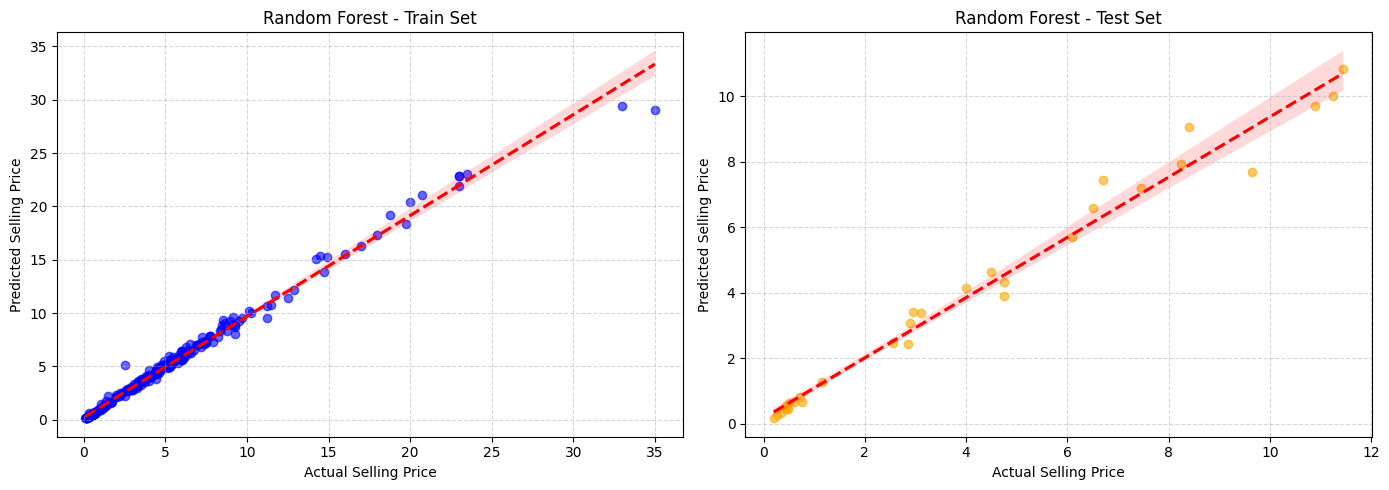

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Train Set
sns.regplot(x=Y_train, y=model3.predict(X_train), ax=ax1,
            scatter_kws={'alpha':0.6, 'color':'blue'},
            line_kws={'color':'red', 'linestyle':'--'})
ax1.set_title('Random Forest - Train Set')
ax1.set_xlabel('Actual Selling Price')
ax1.set_ylabel('Predicted Selling Price')
ax1.grid(True, linestyle='--', alpha=0.5)
# Test Set
sns.regplot(x=Y_test, y=model3.predict(X_test), ax=ax2,
            scatter_kws={'alpha':0.6, 'color':'orange'},
            line_kws={'color':'red', 'linestyle':'--'})
ax2.set_title('Random Forest - Test Set')
ax2.set_xlabel('Actual Selling Price')
ax2.set_ylabel('Predicted Selling Price')
ax2.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()